# 2차 EDA

## `01_user_profile_preprocessed.csv`

| 명칭                               | 형식       | 예시                    | 설명                                |
| -------------------------------- | -------- | --------------------- | --------------------------------- |
| `user_id`                        | string   | `U0000001`            | 사용자 고유 ID                         |
| `signup_date`                    | datetime | `2025-01-25`          | 가입일자                              |
| `signup_channel`                 | string   | `오가닉`                 | 가입경로                              |
| `device`                         | string   | `iOS`                 | 사용 기기                             |
| `notification_agreed`            | bool     | `True`                | 알림 수신 동의 여부                       |
| `notification_changed_date`      | datetime | `2025-05-24`          | 알림 수신 동의 변경일자                     |
| `signup_day`                     | date     | `2025-01-25`          | 파생컬럼: 가입일 기준 날짜                   |
| `signup_month`                   | string   | `2025-01`             | 파생컬럼: 가입월                         |
| `signup_weekday`                 | string   | `토`                   | 파생컬럼: 가입요일                        |
| `first_event_time`               | datetime | `2025-01-25 07:25:45` | 파생컬럼: 사용자별 첫 이벤트 발생 시간            |
| `first_event_elapsed_hours`      | float    | `0.43`                | 파생컬럼: 가입 후 첫 이벤트까지 걸린 시간          |
| `first_app_launch_time`          | datetime | `2025-01-25 07:25:45` | 파생컬럼: 사용자별 첫 앱실행 시간               |
| `app_launch_elapsed_hours`       | float    | `0.43`                | 파생컬럼: 가입 후 첫 앱실행까지 걸린 시간          |
| `onboarding_completed_time`      | datetime | `2025-01-25 07:26:15` | 파생컬럼: 사용자별 첫 온보딩 완료 시간            |
| `onboarding_elapsed_hours`       | float    | `0.44`                | 파생컬럼: 가입 후 온보딩 완료까지 걸린 시간         |
| `app_launch_to_onboarding_hours` | float    | `0.01`                | 파생컬럼: 첫 앱실행 후 온보딩 완료까지 걸린 시간      |
| `event_count_total`              | int      | `35`                  | 파생컬럼: 사용자별 전체 이벤트 수               |
| `avg_events_per_session`         | float    | `3.25`                | 파생컬럼: 사용자별 세션당 평균 이벤트 수           |
| `is_signup_log_issue_period`     | bool     | `False`               | 플래그: 로그 수집 장애 기간 가입 여부            |
| `is_no_event_user`               | bool     | `False`               | 플래그: 프로필에는 있지만 이벤트 로그에는 없는 사용자 여부 |
| `is_onboarding_completed`        | bool     | `True`                | 플래그: 온보딩 완료 여부                    |
| `is_first_event_before_signup`   | bool     | `False`               | 플래그: 첫 이벤트가 가입일보다 빠른지 여부          |

## `02_event_log_preprocessed.csv`

| 명칭                      | 형식       | 예시                    | 설명                      |
| ----------------------- | -------- | --------------------- | ----------------------- |
| `user_id`               | string   | `U0000001`            | 사용자 고유 ID               |
| `event_time`            | datetime | `2025-01-25 07:25:45` | 이벤트 발생 시간               |
| `event_type`            | string   | `앱실행`                 | 이벤트 종류                  |
| `session_id`            | string   | `2858202000`          | 세션 ID, 알림 이벤트는 결측 가능    |
| `notification_type`     | string   | `광고성`                 | 알림 유형, 알림 이벤트에만 값 존재    |
| `event_date`            | date     | `2025-01-25`          | 파생컬럼: 이벤트 발생일           |
| `event_month`           | string   | `2025-01`             | 파생컬럼: 이벤트 발생월           |
| `event_weekday`         | string   | `토`                   | 파생컬럼: 이벤트 발생요일          |
| `event_hour`            | int      | `7`                   | 파생컬럼: 이벤트 발생 시간대        |
| `is_log_issue_period`   | bool     | `False`               | 플래그: 로그 수집 장애 기간 이벤트 여부 |
| `is_event_type_missing` | bool     | `False`               | 플래그: 이벤트 종류 결측 여부       |

# 온보딩 퍼널 분석 더 파보기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

In [6]:
user = pd.read_csv('../../data/processed/01_user_profile_preprocessed.csv', encoding='utf-8-sig')
event = pd.read_csv('../../data/processed/02_Event_Log_preprocessed.csv', encoding='utf-8-sig')

print(user.shape)
print(user.head())

(12500, 23)
    user_id signup_date signup_channel   device notification_agreed  \
0  U0000001  2025-01-25            오가닉      iOS                True   
1  U0000002  2025-05-06            오가닉      iOS               False   
2  U0000003  2025-05-14            오가닉      iOS               False   
3  U0000004  2025-02-23         퍼포먼스광고  Android                True   
4  U0000005  2025-02-18         퍼포먼스광고  Android                True   

  notification_changed_date  signup_day signup_month signup_weekday  \
0                       NaN  2025-01-25      2025-01              토   
1                2025-05-24  2025-05-06      2025-05              화   
2                       NaN  2025-05-14      2025-05              수   
3                       NaN  2025-02-23      2025-02              일   
4                       NaN  2025-02-18      2025-02              화   

      first_event_time  ...  onboarding_completed_time  \
0  2025-01-25 07:25:45  ...        2025-01-25 07:26:15   
1  2025-05-06 16:2

In [ ]:
# 온보딩 완료한 유저와 완료하지 않은 유저의 수 확인
print(user['is_onboarding_completed'].value_counts())
print(f"\n온보딩 완료율: {user['is_onboarding_completed'].sum() / len(user) * 100:.1f}%")

is_onboarding_completed
False    6781
True     5719
Name: count, dtype: int64

온보딩 완료율: 45.8%


1. 온보딩 자체가 너무 어렵거나 길어서 못 끝냄
   → 온보딩 UX 문제

2. 앱 켜자마자 흥미 없어서 그냥 나간 것
   → 앱 자체 또는 마케팅 타겟팅 문제

In [8]:
# 미완료 유저의 총 이벤트 수 분포
not_completed = user[user['is_onboarding_completed'] == False]

print(not_completed['event_count_total'].describe())
print("\n이벤트 1~3건 유저 수:")
print((not_completed['event_count_total'] <= 3).sum())

count    6781.000000
mean      122.741778
std       164.772421
min         0.000000
25%        17.000000
50%        43.000000
75%       161.000000
max       697.000000
Name: event_count_total, dtype: float64

이벤트 1~3건 유저 수:
251


해석
- 미완료 유저 6,781명의 이벤트 수
- 평균 122건(평균 이벤트가 122건이라...)
- 중앙값 43건
- 1~3건 유저 251명 (전체 미완료의 3.7%뿐)
온보딩을 완료 안했는데도 122번이나 했으니깐

1. 온보딩 자체가 너무 어렵거나 길어서 못 끝냄
   → 온보딩 UX 문제  ← 이쪽 가능성 높아짐

2. 앱 켜자마자 흥미 없어서 그냥 나간 것
   → 앱 자체 문제    ← 가능성 낮아짐

In [9]:
# 미완료 유저들의 이벤트 종류 확인
not_completed_ids = user[user['is_onboarding_completed'] == False]['user_id']

event_not_completed = event[event['user_id'].isin(not_completed_ids)]
print(event_not_completed['event_type'].value_counts())

event_type
앱실행       344116
수면기록      117510
알림수신       93368
운동기록       62106
마음챙김       61794
식단기록       48121
챌린지참여      45809
챌린지_탐색     36688
알림오픈       10253
Name: count, dtype: int64


온보딩을 완료하지 않았는데도 앱의 핵심 기능을 전부 사용하고 있다 아... 온보딩이 필수가 아니라 언제든지 건너뛸 수 있는거네.. 그래서 미완료 유저도 평균 122번씩 쓰는거고

이게 반복되면서 온보딩 완료율이 45.8%에 머무는 거구나...

인사이트:
온보딩이 선택적 구조이기 때문에 완료율이 낮고, 온보딩 미완료 유저는 D30 리텐션이 20.1%로 완료 유저(29.5%)보다 낮다. 온보딩을 필수 과정으로 강화하거나 완료 유도 장치가 필요하다

그럼 온보딩을 완료한 유저 5,719명은 언제 완료했을까?

In [10]:
completed = user[user['is_onboarding_completed'] == True]
print(completed['onboarding_elapsed_hours'].describe())

count    5719.000000
mean       14.857077
std         4.609902
min         6.984722
25%        10.870694
50%        14.721667
75%        18.839028
max        23.007778
Name: onboarding_elapsed_hours, dtype: float64


- 최솟값: 6.98시간
- 평균: 14.8시간
- 최댓값: 23.0시간

온보딩을 완료한 유저 5719명은 전원이 가입 당일 24간이내 완료했네..

온보딩은 가입 당일이 유일한 골든타임이다.

당일을 넘기면 완료 확률이 0%일 확률이 높다.

전략 제안 한다면 가입 후 24시간 이내에 온보딩 완료를 유도하는 푸시알림이나 메세지를 보내는??

In [11]:
user.info()

<class 'pandas.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         12500 non-null  str    
 1   signup_date                     12500 non-null  str    
 2   signup_channel                  12363 non-null  str    
 3   device                          12379 non-null  str    
 4   notification_agreed             12384 non-null  object 
 5   notification_changed_date       1976 non-null   str    
 6   signup_day                      12500 non-null  str    
 7   signup_month                    12500 non-null  str    
 8   signup_weekday                  12500 non-null  str    
 9   first_event_time                12453 non-null  str    
 10  first_event_elapsed_hours       12453 non-null  float64
 11  first_app_launch_time           12447 non-null  str    
 12  app_launch_elapsed_hours        12447 non-n

In [12]:
event.info()

<class 'pandas.DataFrame'>
RangeIndex: 1757262 entries, 0 to 1757261
Data columns (total 11 columns):
 #   Column                 Dtype
---  ------                 -----
 0   user_id                str  
 1   event_time             str  
 2   event_type             str  
 3   session_id             str  
 4   notification_type      str  
 5   event_date             str  
 6   event_month            str  
 7   event_weekday          str  
 8   event_hour             int64
 9   is_log_issue_period    bool 
 10  is_event_type_missing  bool 
dtypes: bool(2), int64(1), str(8)
memory usage: 124.0 MB


# 가입 후 정확히 30일째 되는 날 앱을 켠 유저가 몇 %인지 확인

- 가입일자 기준으로 +30일 된 날에
- 앱실행 이벤트가 있으면 → D30 리텐션 카운트

In [13]:
# 날짜 타입 변환
user['signup_date'] = pd.to_datetime(user['signup_date'])
event['event_time'] = pd.to_datetime(event['event_time'])
event['event_date'] = pd.to_datetime(event['event_date'])

# 유저별 가입일자 붙이기
event_with_signup = event.merge(
    user[['user_id', 'signup_date', 'is_onboarding_completed']],
    on='user_id',
    how='left'
)

# 가입일로부터 며칠째인지 계산
event_with_signup['days_since_signup'] = (
    event_with_signup['event_date'] - event_with_signup['signup_date']
).dt.days

print(event_with_signup[['user_id', 'signup_date', 'event_date', 'days_since_signup']].head(10))

    user_id signup_date event_date  days_since_signup
0  U0000001  2025-01-25 2025-01-25                  0
1  U0000001  2025-01-25 2025-01-25                  0
2  U0000001  2025-01-25 2025-01-25                  0
3  U0000001  2025-01-25 2025-01-25                  0
4  U0000001  2025-01-25 2025-01-25                  0
5  U0000001  2025-01-25 2025-01-26                  1
6  U0000001  2025-01-25 2025-01-26                  1
7  U0000001  2025-01-25 2025-01-26                  1
8  U0000001  2025-01-25 2025-01-26                  1
9  U0000001  2025-01-25 2025-01-26                  1


In [14]:
# 앱실행 이벤트만 필터
app_launch = event_with_signup[event_with_signup['event_type'] == '앱실행']

# 온보딩 완료 여부별 D30 리텐션
result = []

for group_name, group_df in app_launch.groupby('is_onboarding_completed'):
    total = group_df['user_id'].nunique()
    d30 = group_df[group_df['days_since_signup'] == 30]['user_id'].nunique()
    retention = d30 / total * 100
    
    result.append({
        '온보딩여부': '완료' if group_name else '미완료',
        '전체유저수': total,
        'D30유저수': d30,
        'D30리텐션(%)': round(retention, 1)
    })

print(pd.DataFrame(result))

  온보딩여부  전체유저수  D30유저수  D30리텐션(%)
0   미완료   6731    1352       20.1
1    완료   5716    1685       29.5


해석 1 (인과관계):
온보딩을 완료했기 때문에
→ 앱 사용법을 제대로 알게 됨
→ 앱이 재미있어짐
→ 30일 뒤에도 계속 씀

해석 2 (상관관계):
원래 앱에 관심 많은 유저가
→ 온보딩도 완료하고
→ 30일 뒤에도 계속 씀
→ 온보딩이 원인이 아닐 수도 있음

온보딩을 완료했기 때문에 리텐션이 높은 건지,

아니면 원래 앱에 관심 많은 유저가 온보딩도 완료하고 리텐션도 높은 건지

온보딩 완료가 리텐션과 강한 상관관계를 보이므로, 온보딩 완료 유도 전략이 유효할 것으로 판단된다. 단, 인과관계 검증을 위해서는 A/B 테스트가 필요하다.

In [ ]:
completed_counts = user['is_onboarding_completed'].value_counts()
labels = ['완료', '미완료']
sizes = [completed_counts[True], completed_counts[False]]
colors = ['steelblue', 'orange']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90)
plt.title('온보딩 완료율')
plt.show()

절반 이상이 온보딩 완료 못함

In [ ]:
result_df = pd.DataFrame(result)
categories = result_df['온보딩여부'].tolist()
values = result_df['D30리텐션(%)'].tolist()
colors = ['steelblue', 'orange']

plt.figure(figsize=(8, 6))
bars = plt.bar(categories, values, color=colors)
plt.title('온보딩 완료 여부별 D30 리텐션')
plt.ylabel('D30 리텐션 (%)')
plt.ylim(0, 40)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

- 온보딩 완료율 45.8% (절반도 안 됨)
         ↓
- 온보딩 완료 유저 D30 29.5%
- 온보딩 미완료 유저 D30 20.1%
         ↓
- 온보딩 완료 시 D30이 1.5배 높다

# 가입 후 온보딩을 완료하기까지 걸린 시간에 따라 D30 리텐션이 달라지는지 확인

- 0~6시간   → 가입하자마자 바로 완료
- 6~12시간  → 당일 중반
- 12~18시간 → 당일 저녁
- 18~24시간 → 자정 직전
- 미완료     → 온보딩 안 함

In [19]:
def classify_onboarding_gap(row):
    if not row['is_onboarding_completed']:
        return '미완료'
    hours = row['onboarding_elapsed_hours']
    if hours <= 6:
        return '0~6시간'
    elif hours <= 12:
        return '6~12시간'
    elif hours <= 18:
        return '12~18시간'
    else:
        return '18~24시간'

user['온보딩갭구간'] = user.apply(classify_onboarding_gap, axis=1)

print("=== 온보딩 갭 구간별 유저 수 ===")
print(user['온보딩갭구간'].value_counts())

=== 온보딩 갭 구간별 유저 수 ===
온보딩갭구간
미완료        6781
12~18시간    2148
6~12시간     1836
18~24시간    1735
Name: count, dtype: int64


0~6은 없네..

In [ ]:
# 구간을 9시간 이내부터로 정하고 확인
def classify_onboarding_gap(row):
    if not row['is_onboarding_completed']:
        return '미완료'
    hours = row['onboarding_elapsed_hours']
    if hours <= 9:
        return '9시간 이내'
    elif hours <= 15:
        return '9~15시간'
    elif hours <= 20:
        return '15~20시간'
    else:
        return '20~24시간'

user['온보딩갭구간'] = user.apply(classify_onboarding_gap, axis=1)

print("=== 온보딩 갭 구간별 유저 수 ===")
print(user['온보딩갭구간'].value_counts())

=== 온보딩 갭 구간별 유저 수 ===
온보딩갭구간
미완료        6781
9~15시간     2213
15~20시간    1747
20~24시간    1015
9시간 이내      744
Name: count, dtype: int64


In [21]:
# 가입일자 붙이기
event_with_signup = event.merge(
    user[['user_id', 'signup_date', '온보딩갭구간']],
    on='user_id',
    how='left'
)

# 가입 후 며칠째인지 계산
event_with_signup['days_since_signup'] = (
    event_with_signup['event_date'] - event_with_signup['signup_date']
).dt.days

# 앱실행만 필터
app_launch = event_with_signup[event_with_signup['event_type'] == '앱실행']

# 구간별 D30 리텐션
result = []
order = ['9시간 이내', '9~15시간', '15~20시간', '20~24시간', '미완료']

for group in order:
    group_df = app_launch[app_launch['온보딩갭구간'] == group]
    total = group_df['user_id'].nunique()
    d30 = group_df[group_df['days_since_signup'] == 30]['user_id'].nunique()
    retention = d30 / total * 100 if total > 0 else 0
    result.append({
        '구간': group,
        '유저수': total,
        'D30리텐션(%)': round(retention, 1)
    })

print(pd.DataFrame(result))

        구간   유저수  D30리텐션(%)
0   9시간 이내   742       26.0
1   9~15시간  2213       31.1
2  15~20시간  1747       29.5
3  20~24시간  1014       28.4
4      미완료  6731       20.1


음... 9~15시간 사이에 온보딩완료한 사람이 d30에도 들어올 확률이 젤 높다라....

1. 온보딩 자체가 길다

온보딩 과정이 9시간 이상 걸릴 만큼 복잡하거나 긴 것

2. 신중하게 완료한 유저

9~15시간 유저는 앱을 켜고 천천히 둘러보다가 온보딩을 완료한 것

→ 앱에 관심이 많은 유저일 가능성

3. 9시간 이내 유저의 특성

너무 빨리 완료한 유저는 대충 넘긴 것일 수도 있음

→ 온보딩 내용을 제대로 안 봤을 가능성

근데 일단 모든 구간이 미완료 보다는 높네.. 그래서 언제 완료했든 간에 온보딩을 완료한 것 자체가 중요한것 같은데..

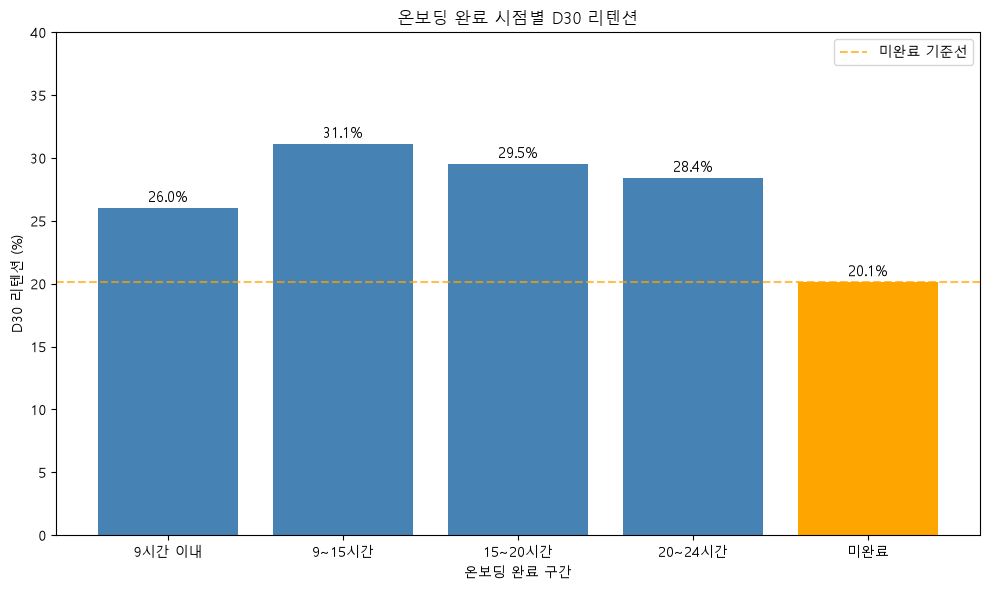

In [22]:
order = ['9시간 이내', '9~15시간', '15~20시간', '20~24시간', '미완료']
values = [26.0, 31.1, 29.5, 28.4, 20.1]
colors = ['steelblue', 'steelblue', 'steelblue', 'steelblue', 'orange']

plt.figure(figsize=(10, 6))
bars = plt.bar(order, values, color=colors)
plt.title('온보딩 완료 시점별 D30 리텐션')
plt.xlabel('온보딩 완료 구간')
plt.ylabel('D30 리텐션 (%)')
plt.ylim(0, 40)

# 수치 표시
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=11)

# 미완료 기준선
plt.axhline(y=20.1, color='orange', linestyle='--', alpha=0.7, label='미완료 기준선')
plt.legend()
plt.tight_layout()
plt.show()

1. 온보딩 완료 자체가 중요 → 완료 유도 장치 필요
2. 골든타임은 가입 당일 24시간 이내
3. 9~15시간 구간이 최적 → 가입 후 반나절 뒤 온보딩 유도 알림이 효과적일 수 있음

가입 후 9시간 뒤 온보딩 완료 유도 푸시알림 발송

## 온보딩 퍼널 분석 결과
1. 온보딩 완료율

전체 12,500명 중 완료 5,719명 → 45.8%
절반 이상(54.2%)이 온보딩 미완료

2. 미완료 유저 행동 패턴

미완료 유저 평균 이벤트 수 122건
1~3건 유저는 251명(3.7%)뿐
→ 온보딩 건너뛰고도 앱 핵심 기능 전부 사용 가능한 구조

3. 온보딩 골든타임

완료 유저 전원이 가입 당일 24시간 이내 완료
당일을 넘기면 완료 확률 0%에 수렴

4. D30 리텐션 비교

완료 유저: 29.5%
미완료 유저: 20.1%
→ 완료 시 D30이 1.5배 높음

5. 온보딩 갭별 D30

9~15시간 구간이 31.1% 로 가장 높음
모든 완료 구간이 미완료(20.1%)보다 높음

인사이트: 
온보딩은 가입 당일이 골든타임이며, 완료 여부가 D30 리텐션의 핵심 분기점인것 같다.

# 세그먼트별 온보딩 완료율

어떤 유저가 온보딩을 더 잘 완료했는지?

볼 세그먼트:

1. iOS vs Android
2. 오가닉 vs 퍼포먼스광고
3. 알림 동의 vs 미동의(이거는 잘 모르겠네...)

In [23]:
# 세그먼트별 온보딩 완료율
segments = ['device', 'signup_channel', 'notification_agreed']
segment_names = ['기기', '가입경로', '알림동의여부']

for seg, name in zip(segments, segment_names):
    print(f"\n=== {name}별 온보딩 완료율 ===")
    result = user.groupby(seg)['is_onboarding_completed'].agg(['sum', 'count'])
    result.columns = ['완료수', '전체수']
    result['완료율(%)'] = (result['완료수'] / result['전체수'] * 100).round(1)
    print(result)


=== 기기별 온보딩 완료율 ===
          완료수   전체수  완료율(%)
device                     
Android  2392  5204    46.0
iOS      3275  7175    45.6

=== 가입경로별 온보딩 완료율 ===
                 완료수   전체수  완료율(%)
signup_channel                    
오가닉             2482  5511    45.0
퍼포먼스광고          3178  6852    46.4

=== 알림동의여부별 온보딩 완료율 ===
                      완료수   전체수  완료율(%)
notification_agreed                    
False                2079  4400    47.2
True                 3583  7984    44.9


- iOS든 Android든 → 완료율 비슷
- 오가닉이든 광고든 → 완료율 비슷
- 알림 동의든 아니든 → 완료율 비슷

→ 특정 유저 그룹이 온보딩을 못 하는 게 아니라

→ 모든 유저가 온보딩을 50% 확률로 완료 못 하는 것

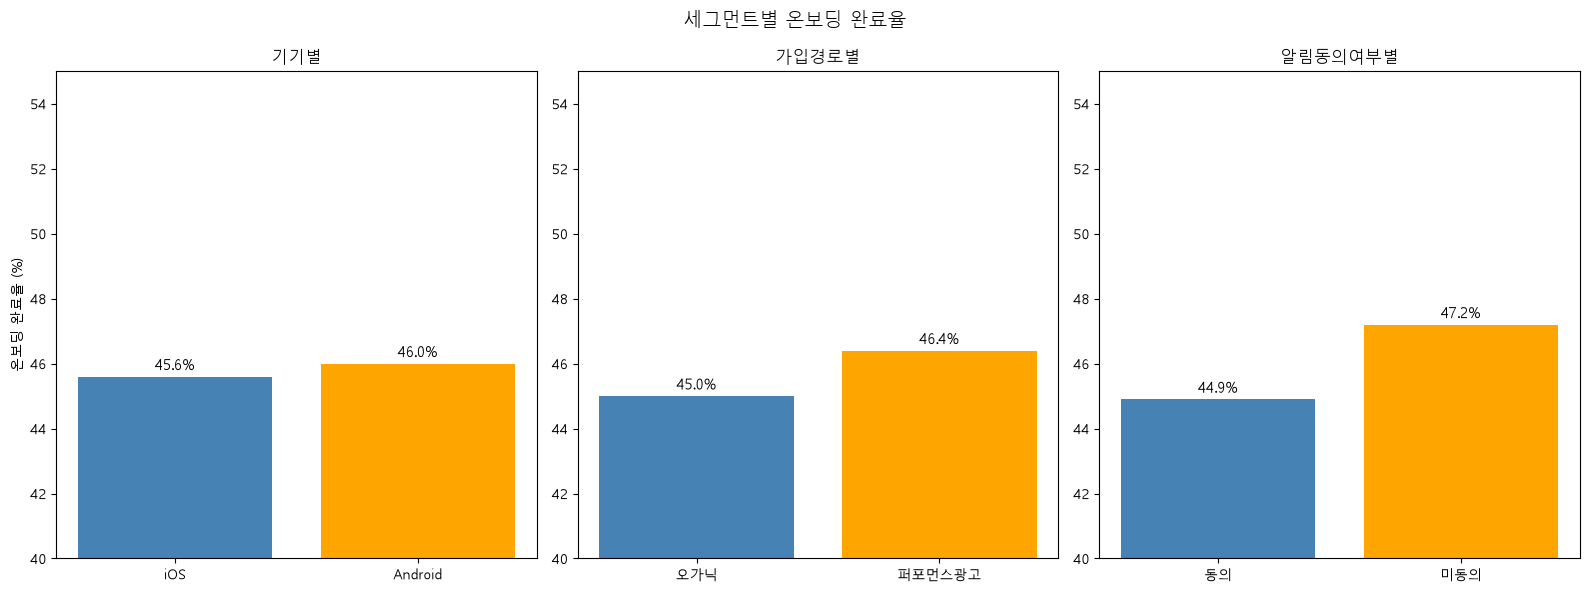

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('세그먼트별 온보딩 완료율', fontsize=14)

# 1. 기기별
device_data = {'iOS': 45.6, 'Android': 46.0}
axes[0].bar(device_data.keys(), device_data.values(), color=['steelblue', 'orange'])
axes[0].set_title('기기별')
axes[0].set_ylabel('온보딩 완료율 (%)')
axes[0].set_ylim(40, 55)
for i, (k, v) in enumerate(device_data.items()):
    axes[0].text(i, v + 0.2, f'{v}%', ha='center', fontsize=11)

# 2. 가입경로별
channel_data = {'오가닉': 45.0, '퍼포먼스광고': 46.4}
axes[1].bar(channel_data.keys(), channel_data.values(), color=['steelblue', 'orange'])
axes[1].set_title('가입경로별')
axes[1].set_ylim(40, 55)
for i, (k, v) in enumerate(channel_data.items()):
    axes[1].text(i, v + 0.2, f'{v}%', ha='center', fontsize=11)

# 3. 알림동의별
noti_data = {'동의': 44.9, '미동의': 47.2}
axes[2].bar(noti_data.keys(), noti_data.values(), color=['steelblue', 'orange'])
axes[2].set_title('알림동의여부별')
axes[2].set_ylim(40, 55)
for i, (k, v) in enumerate(noti_data.items()):
    axes[2].text(i, v + 0.2, f'{v}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

전체 유저 대상으로 온보딩 완료를 유도하는 구조적 개선이 필요할 것 같고 

온보딩을 건너뛸 수 없는 필수 과정으로 변경 가입 후 
9시간 뒤 전체 유저에게 온보딩 완료 유도 알림 발송